In [ ]:
%pip install joblib matplotlib numpy pandas scikit-learn shap xgboost


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)
from thresholding import ThresholdedClassifier
import shap


In [1]:


# Import wrapper module so joblib can deserialize threshold-aware models.


# Load test data
X_test = pd.read_csv(Path(r"data/X_test_selected.csv"))
y_test = pd.read_csv(Path(r"data/y_test.csv")).squeeze("columns")

# Load trained threshold-aware models
logreg_model = joblib.load(Path(r"models/logreg_model.joblib"))
rf_model = joblib.load(Path(r"models/rf_model.joblib"))
xgb_model = joblib.load(Path(r"models/xgb_model.joblib"))
cat_boost = joblib.load(Path(r"models/cat_boost.joblib"))

models = {
    "Logistic Regression": logreg_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_boost,
}

print("Data and threshold-aware models loaded.")
for model_name, model in models.items():
    model_threshold = getattr(model, "threshold", 0.5)
    print(f"{model_name} threshold: {model_threshold:.2f}")


c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickl

Data and threshold-aware models loaded.
Logistic Regression threshold: 0.50
Random Forest threshold: 0.50
XGBoost threshold: 0.50
CatBoost threshold: 0.50


## Apply frozen operating policy from validation on full test set


In [2]:
policy_path = Path(r"models/model_operating_points.csv")

if not policy_path.exists():
    raise FileNotFoundError(
        "Missing models/model_operating_points.csv. Run Modelling.ipynb first to freeze policy on validation."
    )

frozen_policy_df = pd.read_csv(policy_path)
required_cols = {"model", "selected_selection_rate", "derived_threshold"}
missing_cols = required_cols - set(frozen_policy_df.columns)
if missing_cols:
    raise ValueError(f"Operating policy file missing columns: {missing_cols}")

# Evaluate with base estimators even if wrappers are loaded.
models_for_eval = {name: getattr(model, "base_model", model) for name, model in models.items()}

probability_dict = {}
predictions_dict = {}
final_metrics_rows = []

for model_name, model in models_for_eval.items():
    policy_row = frozen_policy_df[frozen_policy_df["model"] == model_name]
    if policy_row.empty:
        raise ValueError(f"No frozen policy found for model: {model_name}")

    threshold = float(policy_row["derived_threshold"].iloc[0])
    selected_rate = float(policy_row["selected_selection_rate"].iloc[0])

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    probability_dict[model_name] = y_prob
    predictions_dict[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob,
        "threshold": threshold,
        "selection_rate": selected_rate,
    }

    prevalence = y_test.mean()
    precision = precision_score(y_test, y_pred, zero_division=0)

    final_metrics_rows.append(
        {
            "model": model_name,
            "frozen_selection_rate_from_validation": selected_rate,
            "frozen_threshold_from_validation": threshold,
            "test_realized_selection_rate": y_pred.mean(),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision,
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_prob),
            "lift_vs_random": (precision / prevalence) if prevalence > 0 else np.nan,
        }
    )

final_metrics_df = pd.DataFrame(final_metrics_rows).sort_values("roc_auc", ascending=False)

print("Frozen policy loaded (chosen on validation only):")
display(frozen_policy_df)

print("Final unbiased test metrics using frozen thresholds:")
display(final_metrics_df)


Frozen policy loaded (chosen on validation only):


,model,selected_selection_rate,derived_threshold,validation_realized_selection_rate,validation_precision,validation_recall,validation_f1,validation_lift_vs_random,selection_rule
0,CatBoost,0.3,0.319947,0.300186,0.808933,0.770686,0.789346,2.567358,first lift drop >= 10% or max lift fallback
1,Logistic Regression,0.2,0.693658,0.200000,0.851024,0.540189,0.660882,2.700946,first lift drop >= 10% or max lift fallback
2,Random Forest,0.3,0.330000,0.300186,0.810174,0.771868,0.790557,2.571296,first lift drop >= 10% or max lift fallback
3,XGBoost,0.3,0.325769,0.300186,0.792804,0.755319,0.773608,2.516169,first lift drop >= 10% or max lift fallback


Final unbiased test metrics using frozen thresholds:


,model,frozen_selection_rate_from_validation,frozen_threshold_from_validation,test_realized_selection_rate,accuracy,precision,recall,f1,roc_auc,lift_vs_random
2,XGBoost,0.3,0.325769,0.554351,0.526816,0.178735,0.846881,0.295174,0.787683,1.527697
3,CatBoost,0.3,0.319947,0.400752,0.661174,0.223234,0.764650,0.345579,0.784209,1.908039
1,Random Forest,0.3,0.330000,0.417892,0.644476,0.214607,0.766541,0.335332,0.780898,1.834302
0,Logistic Regression,0.2,0.693658,0.256331,0.753843,0.248059,0.543478,0.340640,0.724964,2.120222


In [3]:
# Optional operational ranking table for business use (no threshold tuning)
ranking_rows = []
for model_name, y_prob in probability_dict.items():
    ranking_rows.append(
        pd.DataFrame(
            {
                "model": model_name,
                "row_id": np.arange(len(y_prob)),
                "y_true": y_test.values,
                "score": y_prob,
            }
        )
        .sort_values("score", ascending=False)
        .head(20)
    )

ranking_preview_df = pd.concat(ranking_rows, ignore_index=True)
print("Top 20 highest-probability clients per model (test set preview):")
display(ranking_preview_df)


Top 20 highest-probability clients per model (test set preview):


,model,row_id,y_true,score
0,Logistic Regression,2399,1,0.999936
1,Logistic Regression,3873,0,0.999906
2,Logistic Regression,2482,0,0.999905
3,Logistic Regression,4913,0,0.999904
4,Logistic Regression,6485,1,0.999890
...,...,...,...,...
75,CatBoost,2615,0,0.999918
76,CatBoost,879,1,0.999910
77,CatBoost,7197,1,0.999908
78,CatBoost,7091,0,0.999907


In [4]:
policy_vs_test_df = final_metrics_df.merge(
    frozen_policy_df[["model", "selected_selection_rate", "derived_threshold"]],
    on="model",
    how="left",
)

display_cols = [
    "model",
    "selected_selection_rate",
    "derived_threshold",
    "test_realized_selection_rate",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "lift_vs_random",
]

print("Frozen policy vs test outcomes:")
display(policy_vs_test_df[display_cols].sort_values("roc_auc", ascending=False))


Frozen policy vs test outcomes:


,model,selected_selection_rate,derived_threshold,test_realized_selection_rate,precision,recall,f1,roc_auc,lift_vs_random
0,XGBoost,0.3,0.325769,0.554351,0.178735,0.846881,0.295174,0.787683,1.527697
1,CatBoost,0.3,0.319947,0.400752,0.223234,0.764650,0.345579,0.784209,1.908039
2,Random Forest,0.3,0.330000,0.417892,0.214607,0.766541,0.335332,0.780898,1.834302
3,Logistic Regression,0.2,0.693658,0.256331,0.248059,0.543478,0.340640,0.724964,2.120222


## Classification reports e confusion matrixes finais (threshold congelado da valida??o)



Logistic Regression
Frozen selection rate (validation): 20.00% | Frozen threshold (validation): 0.6937


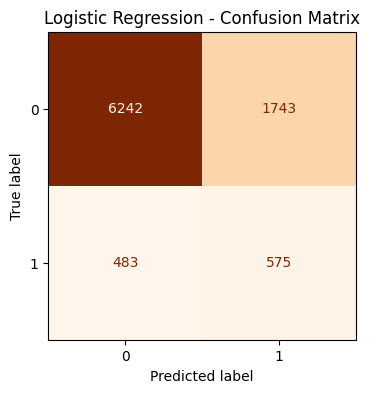


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      7985
           1       0.25      0.54      0.34      1058

    accuracy                           0.75      9043
   macro avg       0.59      0.66      0.59      9043
weighted avg       0.85      0.75      0.79      9043


Random Forest
Frozen selection rate (validation): 30.00% | Frozen threshold (validation): 0.3300


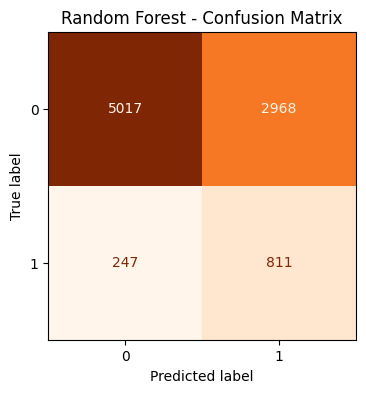


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.63      0.76      7985
           1       0.21      0.77      0.34      1058

    accuracy                           0.64      9043
   macro avg       0.58      0.70      0.55      9043
weighted avg       0.87      0.64      0.71      9043


XGBoost
Frozen selection rate (validation): 30.00% | Frozen threshold (validation): 0.3258


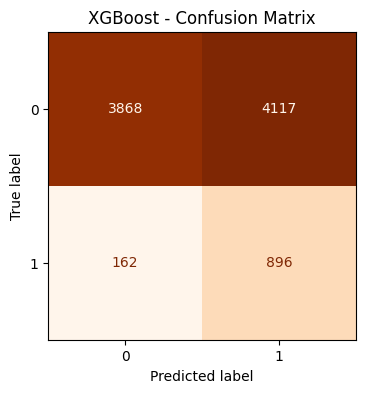


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.48      0.64      7985
           1       0.18      0.85      0.30      1058

    accuracy                           0.53      9043
   macro avg       0.57      0.67      0.47      9043
weighted avg       0.87      0.53      0.60      9043


CatBoost
Frozen selection rate (validation): 30.00% | Frozen threshold (validation): 0.3199


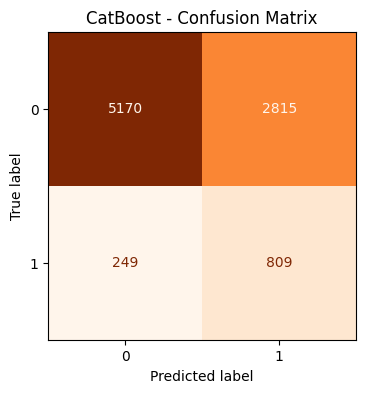


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.65      0.77      7985
           1       0.22      0.76      0.35      1058

    accuracy                           0.66      9043
   macro avg       0.59      0.71      0.56      9043
weighted avg       0.87      0.66      0.72      9043



In [5]:
for model_name, preds in predictions_dict.items():
    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")
    print(
        f"Frozen selection rate (validation): {preds['selection_rate']:.2%} | "
        f"Frozen threshold (validation): {preds['threshold']:.4f}"
    )

    cm = confusion_matrix(y_test, preds["y_pred"])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(
        ax=ax,
        cmap="Oranges",
        colorbar=False,
        values_format="d"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, preds["y_pred"], zero_division=0))


## ROC Curve on full test set (probability ranking quality)


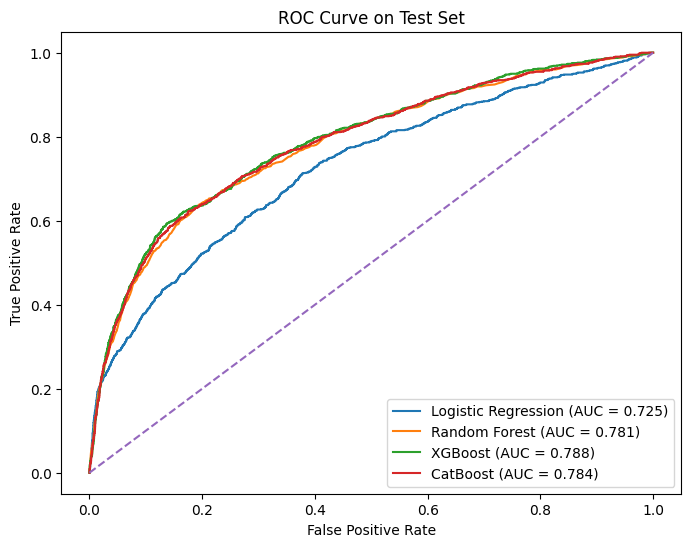

In [6]:
plt.figure(figsize=(8, 6))

for model_name, y_prob in probability_dict.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()


## Final feature importances para Random Forest e XGboost


In [7]:
feature_names = X_test.columns

rf_base = getattr(rf_model, "base_model", rf_model)
xgb_base = getattr(xgb_model, "base_model", xgb_model)
cat_base = getattr(cat_boost, "base_model", cat_boost)

# Random Forest feature importance
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_base.feature_importances_
}).sort_values("importance", ascending=False)

print("Random Forest - Top 15 Feature Importances")
display(rf_importance.head(15))

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_base.feature_importances_
}).sort_values("importance", ascending=False)

print("XGBoost - Top 15 Feature Importances")
display(xgb_importance.head(15))

# CatBoost feature importance
cat_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_base.feature_importances_
}).sort_values("importance", ascending=False)

print("CatBoost - Top 15 Feature Importances")
display(cat_importance.head(15))


Random Forest - Top 15 Feature Importances


,feature,importance
1,balance,0.136048
0,age,0.123400
5,month_sin,0.086779
7,day_sin,0.086033
6,month_cos,0.082067
8,day_cos,0.067812
2,campaign,0.063716
24,housing_yes,0.055892
3,pdays,0.055013
4,previous,0.042664


XGBoost - Top 15 Feature Importances


,feature,importance
28,poutcome_success,0.364156
4,previous,0.130600
24,housing_yes,0.073259
5,month_sin,0.069479
6,month_cos,0.037670
3,pdays,0.027050
19,marital_married,0.026409
22,education_tertiary,0.019725
0,age,0.019597
20,marital_single,0.017510


CatBoost - Top 15 Feature Importances


,feature,importance
5,month_sin,15.990617
6,month_cos,12.069550
0,age,9.816354
7,day_sin,8.703604
24,housing_yes,8.114817
28,poutcome_success,7.925055
3,pdays,7.080254
1,balance,6.720754
8,day_cos,5.956049
2,campaign,4.789992


## Final feature importances para logistic regression


In [8]:
logreg_base = getattr(logreg_model, "base_model", logreg_model)

logreg_importance = pd.DataFrame({
    "feature": X_test.columns,
    "coefficient": logreg_base.coef_[0],
    "abs_coefficient": np.abs(logreg_base.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

print("Logistic Regression - Top 15 Coefficients by Absolute Value")
display(logreg_importance.head(15))


Logistic Regression - Top 15 Coefficients by Absolute Value


,feature,coefficient,abs_coefficient
1,balance,7.707172,7.707172
2,campaign,-5.407678,5.407678
4,previous,4.649850,4.649850
28,poutcome_success,4.579181,4.579181
16,job_student,1.561076,1.561076
13,job_retired,1.522617,1.522617
6,month_cos,1.300408,1.300408
24,housing_yes,-1.253971,1.253971
0,age,-1.180671,1.180671
5,month_sin,0.864982,0.864982


## SHAP analysis


### SHAP para Logistic Regression


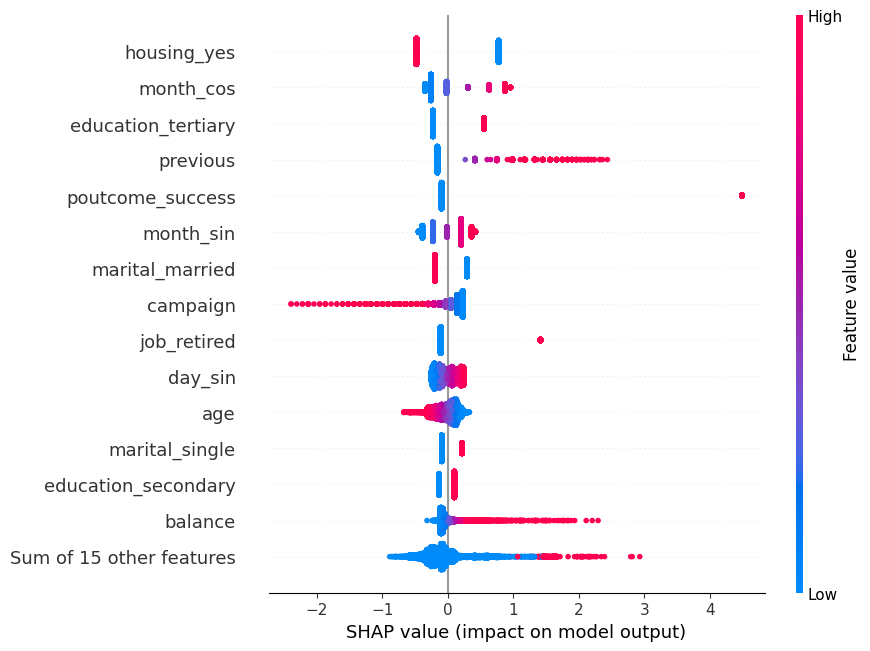

In [9]:

logreg_base = getattr(logreg_model, "base_model", logreg_model)
explainer_logreg = shap.Explainer(logreg_base, X_test)
shap_values_logreg = explainer_logreg(X_test)

shap.plots.beeswarm(shap_values_logreg, max_display=15)


### SHAP para Random Forest


In [ ]:
rf_base = getattr(rf_model, "base_model", rf_model)
explainer_rf = shap.TreeExplainer(rf_base)
shap_values_rf = explainer_rf.shap_values(X_test)

# For binary classification, use class 1 if shap returns a list
if isinstance(shap_values_rf, list):
    shap.summary_plot(shap_values_rf[1], X_test, max_display=15)
else:
    shap.summary_plot(shap_values_rf, X_test, max_display=15)


### SHAP para XGBoost


In [ ]:
xgb_base = getattr(xgb_model, "base_model", xgb_model)
explainer_xgb = shap.TreeExplainer(xgb_base)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, max_display=15)


### SHAP para CatBoost


In [ ]:
cat_base = getattr(cat_boost, "base_model", cat_boost)
explainer_cat = shap.TreeExplainer(cat_base)
shap_values_cat = explainer_cat.shap_values(X_test)

shap.summary_plot(shap_values_cat, X_test, max_display=15)


## Guardar final predictions


In [ ]:
predictions_df = X_test.copy()
predictions_df["y_true"] = y_test.values

for model_name, preds in predictions_dict.items():
    safe_name = model_name.lower().replace(" ", "_")
    predictions_df[f"{safe_name}_pred"] = preds["y_pred"]
    predictions_df[f"{safe_name}_prob"] = preds["y_prob"]

predictions_df.to_csv(Path(r"data/test_set_predictions.csv"), index=False)
final_metrics_df.to_csv(Path(r"data/test_set_final_metrics_frozen_policy.csv"), index=False)

print("Predictions saved to data/test_set_predictions.csv")
print("Final metrics saved to data/test_set_final_metrics_frozen_policy.csv")
display(predictions_df.head())
display(final_metrics_df)
